In [ ]:
import pandas as pd

In [ ]:
df_raw = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/global_temp_dirty_v2.csv")


In [ ]:
stripped_columns = [col.strip() for col in df_raw.columns]
df_raw.columns = stripped_columns
df_raw = df_raw[["Date", "Temperature_Anomaly"]]
mask_end_of_data = df_raw["Date"] == "END OF DATA"
idx_eod_of_data = df_raw[mask_end_of_data].index[0]
df_raw = df_raw.iloc[:idx_eod_of_data, :]
df_raw = df_raw.loc[~pd.isna(df_raw).all(axis=1)]
num_total = df_raw.shape[0]

In [ ]:
import datetime as dt
import numpy as np
def try_parse_datetime(val, max_year: int = 2025) -> np.datetime64:
  dt_obj = pd.to_datetime(val, errors="coerce")
  if pd.isna(dt_obj):
    return None
  if dt_obj.year > max_year and dt_obj.year < 2100:
    return dt_obj.replace(year=dt_obj.year - 100).to_datetime64()
  return dt_obj.to_datetime64()

In [ ]:
mask_swapped_fields = df_raw["Temperature_Anomaly"].apply(lambda x: try_parse_datetime(x, max_year=2026)).dropna().index
count_swap = mask_swapped_fields.shape[0]
actual_date_vals = df_raw.loc[mask_swapped_fields, "Temperature_Anomaly"]
actual_value_vals = df_raw.loc[mask_swapped_fields, "Date"]
df_raw.loc[mask_swapped_fields, "Date"] = actual_date_vals
df_raw.loc[mask_swapped_fields, "Temperature_Anomaly"] = actual_value_vals
# Convert every date to a datetime64 value
df_raw["Date Cleaned"] = df_raw["Date"].apply(lambda x: try_parse_datetime(x, max_year=2026))

In [ ]:
# Date Cleaned: Null Value, Not Increasingn, Duplicate
error_log = []

for i in range(df_raw.shape[0]):
  if i == 0:
    if df_raw.loc[0, "Date Cleaned"] == None:
      error_log.append({
          "Index": i,
          "Error": "Null Value"
      })
  else:
    current_row = df_raw.loc[i, :]
    previous_row = df_raw.loc[i - 1, :]
    if pd.isna(current_row["Date Cleaned"]):
      error_log.append({
          "Index": i,
          "Error": "Null Value"
      })
    elif not pd.isna(previous_row["Date Cleaned"]) and current_row["Date Cleaned"] == previous_row["Date Cleaned"]:
      error_log.append({
          "Index": i,
          "Error": "Duplicate"
      })
    elif not pd.isna(previous_row["Date Cleaned"]) and current_row["Date Cleaned"] < previous_row["Date Cleaned"]:
      error_log.append({
          "Index": i,
          "Error": "Not Increasing"
      })


In [ ]:
df_error_log = pd.DataFrame(error_log)
df_error_log.groupby("Error").count()

,Index
Error,
Duplicate,7
Not Increasing,257
Null Value,214


In [ ]:
index_to_remove = df_error_log[df_error_log["Error"].isin(["Duplicate", "Not Increasing"])]["Index"]

In [ ]:
index_to_keep = [i for i in range(df_raw.shape[0]) if i not in index_to_remove]

In [ ]:
df_processed = df_raw.loc[index_to_keep].reset_index(drop=True).copy()

In [ ]:

# Absent months: some calendar months have no row at all.

In [ ]:
# Sensor-malfunction codes: 500, -500, 999, and -999. These are not physical temperatures.
def check_malfunction_code(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
  sensor_malfunction_codes = [500, -500, 999, -999, "500", "-500", "999", "-999"]
  mask_malfunction_codes = df["Temperature_Anomaly"].isin(sensor_malfunction_codes)
  return df[~mask_malfunction_codes].copy(), mask_malfunction_codes.sum()

In [ ]:
df_processed_1, ct = check_malfunction_code(df_processed)
print("Sensor Malfunction Code Count:", ct)

Sensor Malfunction Code Count: 53


In [ ]:
# Inconsistent numeric formatting, including comma decimal separators ("-0,199") and a unit suffix (0.253°C).
def check_numeric_formatting(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
  # fix comma decimal separators
  def _check(val: str | float) -> tuple[bool, float]:
    flag = False
    if isinstance(val, str) and "," in val:
      flag = True
      val = float(val.replace(",", "."))

    if isinstance(val, str) and "°" in val:
      flag = True
      val = float(val.replace("°C", "").replace("°F", ""))

    return flag, val

  records = []
  col_index = df.columns.get_loc("Temperature_Anomaly")

  for i, row in df.iterrows():
    bool_flag, val_after = _check(row["Temperature_Anomaly"])
    if bool_flag:
      records.append({
          "Index": i,
          "Original Value": row["Temperature_Anomaly"],
          "Fixed Value": val_after
      })
      df.loc[i, "Temperature_Anomaly"] = val_after


  df_log = pd.DataFrame(records)
  return df, df_log

In [ ]:
df_processed_2, df_numeric_formatting_log = check_numeric_formatting(df_processed_1)

In [ ]:
df_numeric_formatting_log

,Index,Original Value,Fixed Value
0,41,-0.821°C,-0.821
1,47,-0.67°C,-0.670
2,68,-0.539°C,-0.539
3,72,"-0,601",-0.601
4,104,-0.525°C,-0.525
...,...,...,...
61,1351,"0,839",0.839
62,1376,"0,98",0.980
63,1400,"0,970",0.970
64,1419,1.179°C,1.179


In [ ]:
df_processed_2

,Date,Temperature_Anomaly,Date Cleaned
0,Feb-1880,-0.752,1880-02-01
1,Feb-1880,-0.752,1880-02-01
2,1880.04,-0.593,1880-04-01
3,1880-05-01,-0.739,1880-05-01
4,1887/01,-0.758,1887-01-01
...,...,...,...
1438,Aug-25,0.999,NaT
1439,Sep-25,.,NaT
1440,Oct-25,1.016,NaT
1441,Nov-25,0.985,NaT


In [ ]:
# first check missing dates unique
mask_failed_date_parsing = df_processed_2["Date Cleaned"].isna()
df_processed_2[mask_failed_date_parsing]["Date"].unique()

array(['191307', '192007', '192103', '192203', 'Feb-27', 'Sep-28',
       'Apr-28', 'Jul-26', 'Jul-28', 'Jan-26', 'Sep-27', 'Jul-27',
       'Oct-26', 'Apr-26', 'Aug-27', 'Feb-26', 'Mar-26', 'May-27',
       'Dec-27', 'May-28', 'Feb-28', 'Oct-27', 'Nov-27', 'Oct-28',
       'Nov-28', 'Feb-29', 'May-29', 'Jun-29', 'Jul-29', 'Aug-29',
       'Feb-30', '193006', 'Aug-30', 'Sep-30', 'Dec-30', 'Jan-31',
       'Mar-31', 'May-31', 'Jun-31', 'Jul-31', 'Sep-31', 'Nov-31',
       '193206', '193312', '193604', '194608', '195101', '195806',
       '196111', '196507', '197209', '197508', '198403', '198712',
       '198505', '198411', '198804', '199306', '199303', 'Mar-01',
       'Jul-00', 'May-00', 'Apr-00', 'Dec-00', 'Jul-01', 'Oct-01',
       'Jan-02', 'Feb-02', 'May-02', 'Oct-02', 'Mar-03', 'Apr-03',
       'Aug-03', '0.512', 'Dec-03', 'Feb-04', 'Aug-04', 'Sep-04',
       'Oct-04', 'Dec-04', 'Jan-05', 'Feb-05', 'Aug-05', '0.64', 'Jan-07',
       'Jun-07', 'Aug-07', 'Sep-07', 'Nov-07', 'Dec-07'

In [ ]:
# Missing-value tokens: blank, ., --, NaN, null, NA, N/A, #N/A, n/a, and missing.
# Mixed date formats, for example 188001, 1880/03, 1880.04, 1880-05-01, 11/1880, Jun 1880, Jan-1990, 1908 Sep, Jan-43, and 7/1/07.
def fix_date_6_digit(df_raw: pd.DataFrame) -> tuple[pd.DataFrame, int]:
  # if Date is str and is numeric and len is 6
  ct = 0
  df = df_raw.copy()
  for idx, row in df.iterrows():
    if pd.isna(row["Date Cleaned"]) and isinstance(row["Date"], str) and row["Date"].isnumeric() and len(row["Date"]) == 6:
      year = row["Date"][:4]
      month = row["Date"][4:6]
      df.loc[idx, "Date Cleaned"] = np.datetime64(f"{year}-{month}-01")
      ct += 1
  return df, ct

In [ ]:
df_processed_3, ct_date_six_digit = fix_date_6_digit(df_processed_2)
print("Date Six Digit Count:", ct_date_six_digit)

Date Six Digit Count: 25


In [ ]:
# Month-Year
def fix_date_month_year(df_raw: pd.DataFrame) -> tuple[pd.DataFrame, int]:
  # if three digit month code, hyphen, two digit
  ct = 0
  df = df_raw.copy()
  for idx, row in df.iterrows():
    if pd.isna(row["Date Cleaned"]) and isinstance(row["Date"], str) and "-" in row["Date"]:
      try:
        month_code, year_short = row["Date"].split("-")
        if len(month_code) == 3 and len(year_short) == 2:
          if int(year_short) <= 26:
            year = 2000 + int(year_short)
          else:
            year = 1900 + int(year_short)

          # convert 3-letter monthcode into month
          month = dt.datetime.strptime(month_code, "%b").month
          df.loc[idx, "Date Cleaned"] = dt.datetime(year, month, 1)
          ct += 1
      except Exception as e:
        print(e)
  return df, ct

In [ ]:
df_processed_4, ct_date_month_year = fix_date_month_year(df_processed_3)
print("Date Month-Year:", ct_date_month_year)

Date Month-Year: 169


In [ ]:
# first check missing dates unique
mask_failed_date_parsing = df_processed_4["Date Cleaned"].isna()
df_processed_4[mask_failed_date_parsing]["Date"].unique()

array(['0.512', '0.64', '0.832', '1.032', '1.138'], dtype=object)

In [ ]:
df_processed_4[mask_failed_date_parsing]

,Date,Temperature_Anomaly,Date Cleaned
1186,0.512,Nov-03,NaT
1210,0.64,Jan-06,NaT
1253,0.832,Nov-09,NaT
1398,1.032,Mar-22,NaT
1399,1.138,Apr-22,NaT


In [ ]:
actual_val_series = df_processed_4.loc[mask_failed_date_parsing, "Date"]
actual_date_series = df_processed_4.loc[mask_failed_date_parsing, "Temperature_Anomaly"]
df_processed_5 = df_processed_4.copy()
df_processed_5.loc[mask_failed_date_parsing, "Temperature_Anomaly"] = actual_val_series
df_processed_5.loc[mask_failed_date_parsing, "Date"] = actual_date_series

In [ ]:
count_swap += mask_failed_date_parsing.sum()

NameError: name 'count_swap' is not defined

In [ ]:
 df_processed_6, ct_date_month_year_extra = fix_date_month_year(df_processed_5)
 ct_date_month_year += ct_date_month_year_extra

In [ ]:
count_duplicate_extra = df_processed_6.shape[0] - df_processed_6["Date Cleaned"].drop_duplicates().shape[0]

In [ ]:
df_processed_6 = df_processed_6.drop_duplicates(["Date Cleaned"])

In [ ]:
df_processed_6[df_processed_6["Date Cleaned"] > dt.datetime(2026, 1, 1)]

,Date,Temperature_Anomaly,Date Cleaned
253,5/1/26,-0.276,2026-05-01
264,Jul-26,-0.25,2026-07-01
268,9/1/26,-0.30,2026-09-01
272,Oct-26,-0.160,2026-10-01
273,Apr-26,-0.264,2026-04-01
277,Feb-26,-0.238,2026-02-01
279,Mar-26,-0.212,2026-03-01


<Axes: >

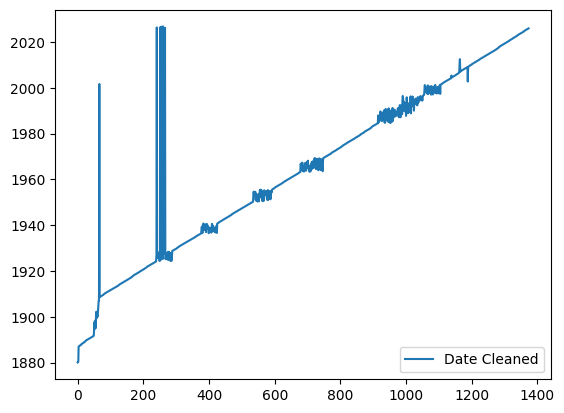

In [ ]:
df_processed_6[["Date Cleaned"]].reset_index(drop=True).plot()

In [ ]:
# define healthy mask: larger than prev and smaller than next
mask_healthy_1 = df_processed_6["Date Cleaned"] > df_processed_6["Date Cleaned"].shift(1)
mask_healthy_2 = df_processed_6["Date Cleaned"] < df_processed_6["Date Cleaned"].shift(-1)
mask_healthy = mask_healthy_1 & mask_healthy_2
ct_mask_healthy = mask_healthy.sum()
df_processed_7 = df_processed_6[mask_healthy].reset_index(drop=True)

<Axes: >

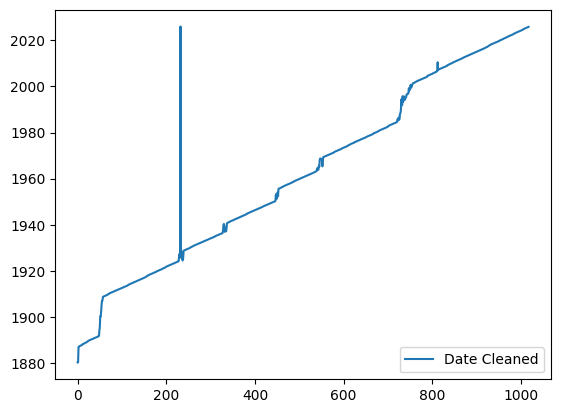

In [ ]:
df_processed_7[["Date Cleaned"]].reset_index(drop=True).plot()

In [ ]:
# clean again
mask_healthy_a = df_processed_7["Date Cleaned"] > df_processed_7["Date Cleaned"].shift(1)
mask_healthy_b = df_processed_7["Date Cleaned"] < df_processed_7["Date Cleaned"].shift(-1)
mask_healthy = mask_healthy_a & mask_healthy_b
ct_mask_healthy_again = mask_healthy.sum()
df_processed_8 = df_processed_7[mask_healthy].reset_index(drop=True)

<Axes: >

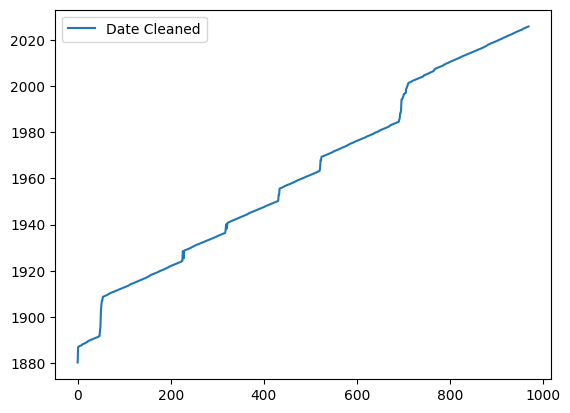

In [ ]:
df_processed_8[["Date Cleaned"]].reset_index(drop=True).plot()

In [ ]:
# check if Date Cleaned not increasing
mask_not_increasing = df_processed_8["Date Cleaned"] < df_processed_8["Date Cleaned"].shift(1)
ct_not_increasing_extra = mask_not_increasing.sum()
df_processed_9 = df_processed_8[~mask_not_increasing].reset_index(drop=True).copy()

In [ ]:
mask_not_increasing = df_processed_9["Date Cleaned"] < df_processed_9["Date Cleaned"].shift(1)
ct_not_increasing_extra_extra = mask_not_increasing.sum()
df_processed_10 = df_processed_9[~mask_not_increasing].reset_index(drop=True).copy()

In [ ]:
(df_processed_10["Date Cleaned"] < df_processed_10["Date Cleaned"].shift(1)).sum()

np.int64(0)

In [ ]:
def parse_temperature_val(df_raw: pd.DataFrame) -> tuple[pd.DataFrame, int]:
  from pandas.api.types import is_numeric_dtype
  ct = 0
  df = df_raw.copy()

  idx_list_to_keep = []

  for idx, row in df.iterrows():
    val_raw = row["Temperature_Anomaly"]
    if val_raw == '.' or val_raw == 'missing' or val_raw == '--' or val_raw == 'NaN' or val_raw == 'null' or val_raw == '   ' or val_raw == '.':
      ct += 1
      df.loc[idx, "Temperature_Anomaly"] = None
    else:
      val_parsed = float(row["Temperature_Anomaly"])
      df.loc[idx, "Temperature_Anomaly"] = val_parsed
      idx_list_to_keep.append(idx)

  df = df.loc[idx_list_to_keep, :].reset_index(drop=True)
  return df, ct

In [ ]:
df_clean, ct_bad_value = parse_temperature_val(df_processed_10)

<Axes: xlabel='Date Cleaned'>

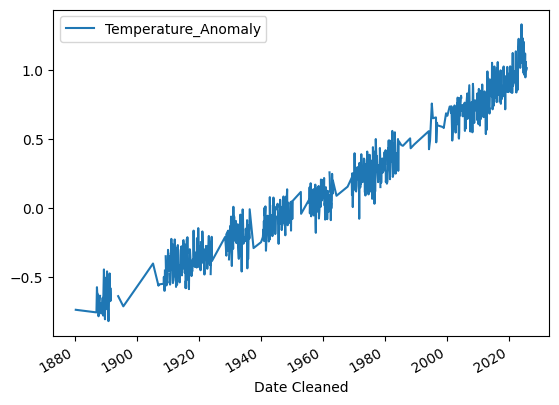

In [ ]:
df_clean[["Date Cleaned", "Temperature_Anomaly"]].plot(x="Date Cleaned", y="Temperature_Anomaly")

In [ ]:
# set to 1 of each month
df_clean["Date Cleaned"] = df_clean["Date Cleaned"].apply(lambda x: x.replace(day=1))

In [ ]:
df_clean = df_clean[["Date Cleaned", "Temperature_Anomaly"]].reset_index(drop=True)

In [ ]:
df_clean.to_csv("/content/drive/MyDrive/Colab Notebooks/global_temp_clean.csv")